# Comparison between the recommender systems

This notebook compares different recommender systems in terms of various metrics. We benchmark the
algorithms on the MovieLens 100k dataset and Movielens 1M dataset. 

Copyright 2023 Bernardo C. Rodrigues

See COPYING file for license details

In [1]:
# Setup notebook
import random
import numpy as np
import evaluation.plot as plot

# Load the autoreload extension
%load_ext autoreload

# Set autoreload to reload all modules every time a cell is executed
%autoreload 2

# Call the function to customize the default template
plot.customize_default_template()

seed = 0
random.seed(seed)
np.random.seed(seed)

In [10]:
# Load folds
from dataset.movie_lens import load_ml_100k_folds, resolve_folds

folds = resolve_folds(*load_ml_100k_folds(predefined=True))

Already downloaded!. Nothing to do.


In [11]:
# Threshold that defines wether a rating is considered relevant in the metrics computation.
RELEVANCE_THRESHOLD = 4.0

# Number of top recommendations to be considered in the metrics computation (e.g. precision@k).
NUMBER_OF_TOP_RECOMMENDATIONS = 20

# Number of times the each experiment should be repeated. Keep in mind that an experiment already
# involves a 5 fold cross validation.
REPEAT = 1

In [34]:
# Define the recommender variations to be used in the experiments.
from surprise.prediction_algorithms import (
    SVD,
    KNNWithMeans,
    CoClustering,
)
from recommenders import grecond_recommender, binaps_based_recommenders, common
import evaluation.threads as threads

parallel_recommender_variations = [
    threads.RecommenderVariation(
        "GreConD+IBCAkNN",
        grecond_recommender.GreConDBiAKNNRecommender(
            grecond_coverage=0.1,
            dataset_binarization_threshold=1.0,
            minimum_bicluster_sparsity=None,
            minimum_bicluster_coverage=None,
            minimum_bicluster_relative_size=None,
            knn_type="item",
            user_binarization_threshold=1.0,
            number_of_top_k_biclusters=100,
            knn_k=50,
        ),
    ),
    threads.RecommenderVariation(
        "IBkNN",
        KNNWithMeans(sim_options={"name": "cosine", "user_based": False}, verbose=False),
    ),
    threads.RecommenderVariation(
        "GreConD+UBCAkNN",
        grecond_recommender.GreConDBiAKNNRecommender(
            grecond_coverage=0.2,
            dataset_binarization_threshold=1.0,
            minimum_bicluster_sparsity=None,
            minimum_bicluster_coverage=None,
            minimum_bicluster_relative_size=None,
            knn_type="user",
            user_binarization_threshold=4.0,
            number_of_top_k_biclusters=None,
            knn_k=50,
        ),
    ),
    threads.RecommenderVariation(
        "UBkNN",
        KNNWithMeans(sim_options={"name": "cosine", "user_based": True}, verbose=False),
    ),
    threads.RecommenderVariation("SVD", SVD(verbose=False)),
    threads.RecommenderVariation("CoClustering", CoClustering(verbose=False)),
    (
        "GreConD+MF+UBkNN",
        grecond_recommender.GreConDKNNRecommender(
            grecond_coverage=1.0,
            dataset_binarization_threshold=1.0,
            knn_k=30,
            knn_distance_strategy=common.get_cosine_similarity_matrix,
        ),
    ),
]

sequential_recommender_variations = [
    threads.RecommenderVariation(
        "BinaPs+IBCAkNN",
        binaps_based_recommenders.BinaPsKNNRecommender(
            epochs=100,
            dataset_binarization_threshold=2.5,
            minimum_bicluster_sparsity=None,
            minimum_bicluster_coverage=None,
            minimum_bicluster_relative_size=None,
            knn_type="item",
            user_binarization_threshold=0.0,
            number_of_top_k_biclusters=5,
            knn_k=10,
        ),
    )
]

In [35]:
# Run the benchmarks on MovieLens 100k
from evaluation.plot import benchmark
from evaluation.threads import generic_benchmark_thread

results = benchmark(
    folds,
    parallel_recommender_variations,
    sequential_recommender_variations,
    REPEAT,
    RELEVANCE_THRESHOLD,
    NUMBER_OF_TOP_RECOMMENDATIONS,
    generic_benchmark_thread,
)

2024-02-29 14:39:27,954 - recommenders - INFO - Generating Formal Context...
2024-02-29 14:39:28,522 - recommenders - INFO - Generating Formal Context...
2024-02-29 14:39:29,411 - recommenders - INFO - Generating Formal Context...
2024-02-29 14:39:31,120 - recommenders - INFO - Generating Formal Context...
2024-02-29 14:39:34,754 - recommenders - INFO - Generating Formal Context...
2024-02-29 14:40:34,911 - recommenders - INFO - Generating Formal Context OK
2024-02-29 14:40:34,912 - recommenders - INFO - Generating Similarity Matrix...
2024-02-29 14:40:37,494 - recommenders - INFO - Generating Similarity Matrix OK
2024-02-29 14:40:39,220 - recommenders - INFO - Generating Formal Context OK
2024-02-29 14:40:39,221 - recommenders - INFO - Generating Similarity Matrix...
2024-02-29 14:40:41,786 - recommenders - INFO - Generating Similarity Matrix OK
2024-02-29 14:40:58,558 - recommenders - INFO - Generating Formal Context OK
2024-02-29 14:40:58,559 - recommenders - INFO - Generating Simil

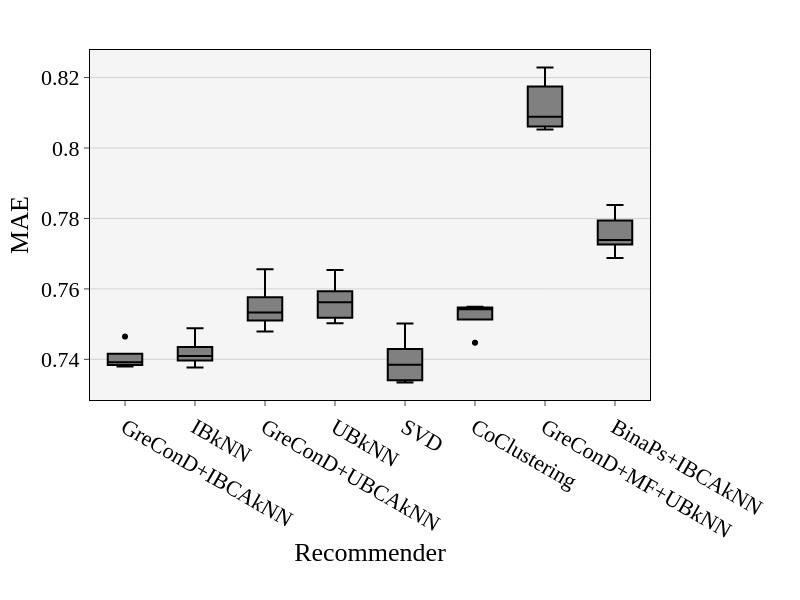

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.740 & 0.003 & 0.738 & 0.746 \\
IBkNN & 0.742 & 0.004 & 0.738 & 0.749 \\
GreConD+UBCAkNN & 0.755 & 0.006 & 0.748 & 0.766 \\
UBkNN & 0.756 & 0.005 & 0.750 & 0.765 \\
SVD & 0.739 & 0.006 & 0.733 & 0.750 \\
CoClustering & 0.752 & 0.004 & 0.745 & 0.755 \\
GreConD+MF+UBkNN & 0.812 & 0.007 & 0.805 & 0.823 \\
BinaPs+IBCAkNN & 0.776 & 0.005 & 0.769 & 0.784 \\
\bottomrule
\end{tabular}



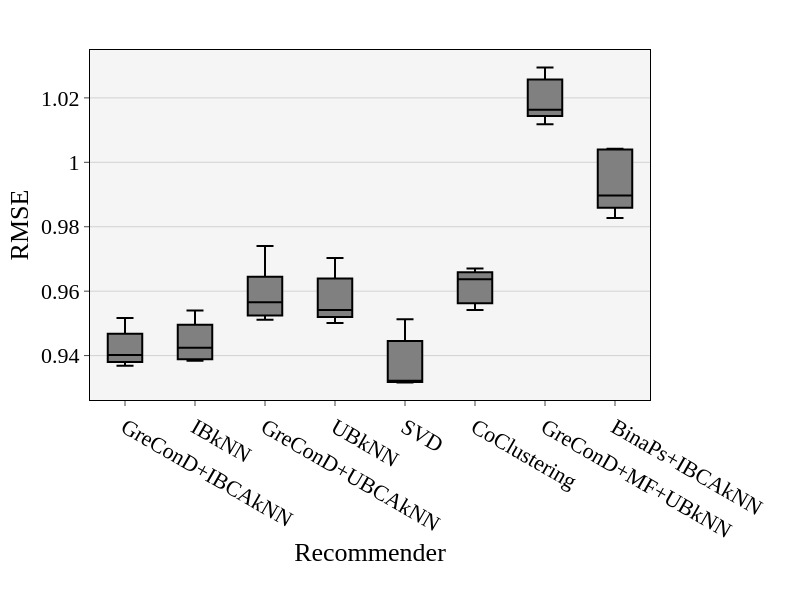

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.942 & 0.005 & 0.937 & 0.952 \\
IBkNN & 0.944 & 0.006 & 0.938 & 0.954 \\
GreConD+UBCAkNN & 0.959 & 0.008 & 0.951 & 0.974 \\
UBkNN & 0.958 & 0.007 & 0.950 & 0.970 \\
SVD & 0.938 & 0.008 & 0.932 & 0.951 \\
CoClustering & 0.961 & 0.005 & 0.954 & 0.967 \\
GreConD+MF+UBkNN & 1.019 & 0.006 & 1.012 & 1.029 \\
BinaPs+IBCAkNN & 0.994 & 0.009 & 0.983 & 1.004 \\
\bottomrule
\end{tabular}



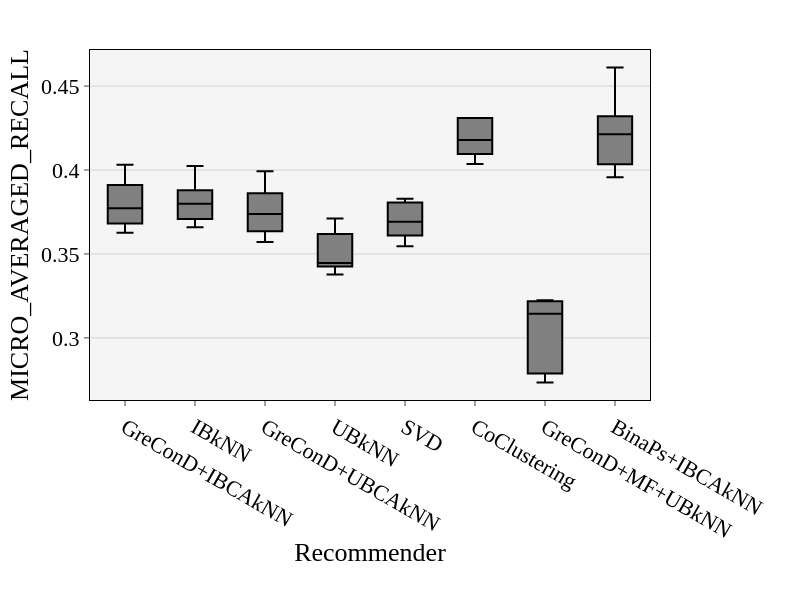

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.380 & 0.014 & 0.363 & 0.403 \\
IBkNN & 0.381 & 0.012 & 0.366 & 0.402 \\
GreConD+UBCAkNN & 0.376 & 0.014 & 0.357 & 0.399 \\
UBkNN & 0.351 & 0.012 & 0.338 & 0.371 \\
SVD & 0.370 & 0.010 & 0.355 & 0.383 \\
CoClustering & 0.419 & 0.011 & 0.404 & 0.431 \\
GreConD+MF+UBkNN & 0.303 & 0.021 & 0.273 & 0.322 \\
BinaPs+IBCAkNN & 0.421 & 0.022 & 0.396 & 0.461 \\
\bottomrule
\end{tabular}



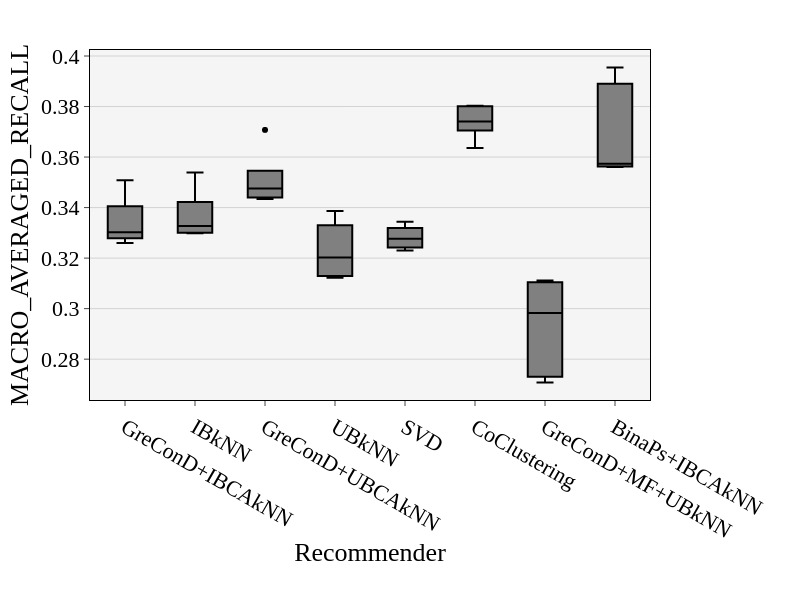

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.335 & 0.009 & 0.326 & 0.351 \\
IBkNN & 0.337 & 0.009 & 0.330 & 0.354 \\
GreConD+UBCAkNN & 0.351 & 0.010 & 0.343 & 0.371 \\
UBkNN & 0.323 & 0.010 & 0.312 & 0.339 \\
SVD & 0.328 & 0.004 & 0.323 & 0.334 \\
CoClustering & 0.374 & 0.006 & 0.364 & 0.380 \\
GreConD+MF+UBkNN & 0.293 & 0.017 & 0.271 & 0.311 \\
BinaPs+IBCAkNN & 0.370 & 0.017 & 0.356 & 0.395 \\
\bottomrule
\end{tabular}



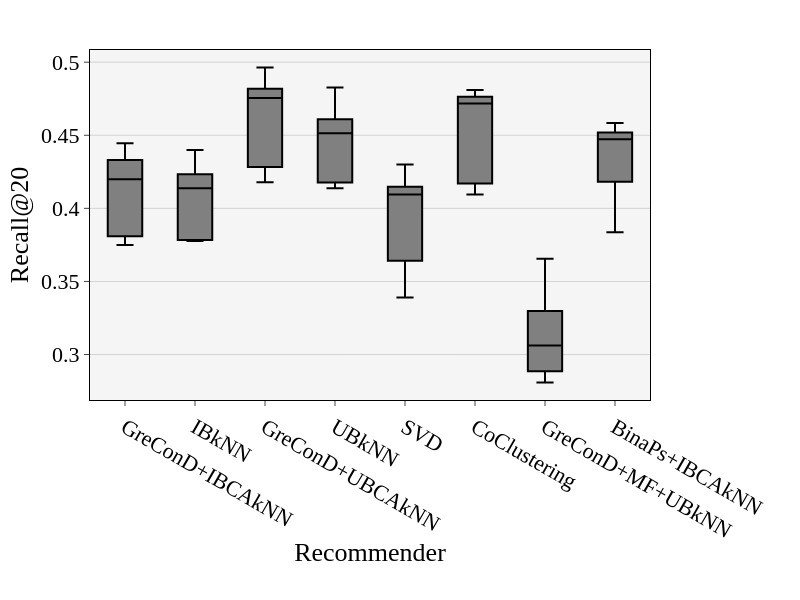

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.410 & 0.027 & 0.375 & 0.444 \\
IBkNN & 0.406 & 0.024 & 0.378 & 0.440 \\
GreConD+UBCAkNN & 0.460 & 0.030 & 0.418 & 0.496 \\
UBkNN & 0.444 & 0.025 & 0.414 & 0.483 \\
SVD & 0.392 & 0.032 & 0.339 & 0.430 \\
CoClustering & 0.451 & 0.030 & 0.410 & 0.481 \\
GreConD+MF+UBkNN & 0.312 & 0.029 & 0.281 & 0.365 \\
BinaPs+IBCAkNN & 0.434 & 0.027 & 0.384 & 0.458 \\
\bottomrule
\end{tabular}



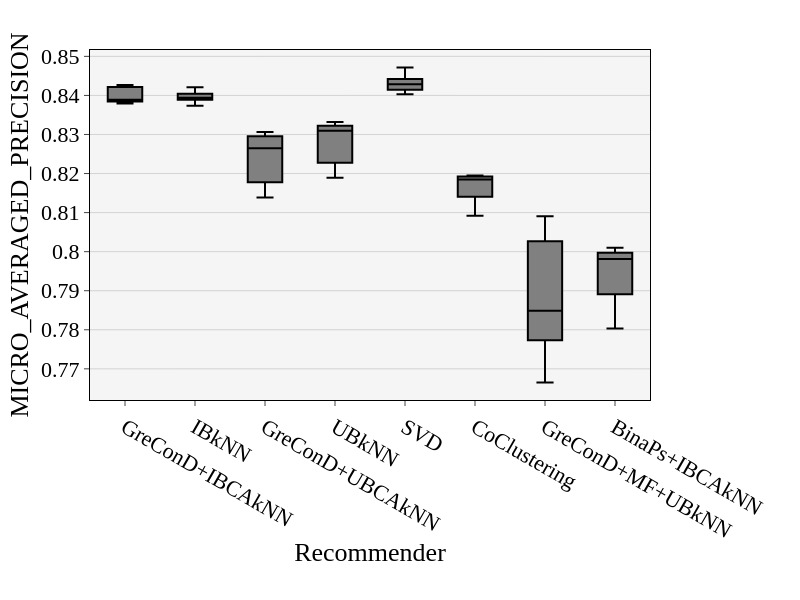

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.840 & 0.002 & 0.838 & 0.843 \\
IBkNN & 0.840 & 0.001 & 0.837 & 0.842 \\
GreConD+UBCAkNN & 0.824 & 0.006 & 0.814 & 0.831 \\
UBkNN & 0.828 & 0.005 & 0.819 & 0.833 \\
SVD & 0.843 & 0.002 & 0.840 & 0.847 \\
CoClustering & 0.816 & 0.004 & 0.809 & 0.819 \\
GreConD+MF+UBkNN & 0.788 & 0.015 & 0.767 & 0.809 \\
BinaPs+IBCAkNN & 0.794 & 0.008 & 0.780 & 0.801 \\
\bottomrule
\end{tabular}



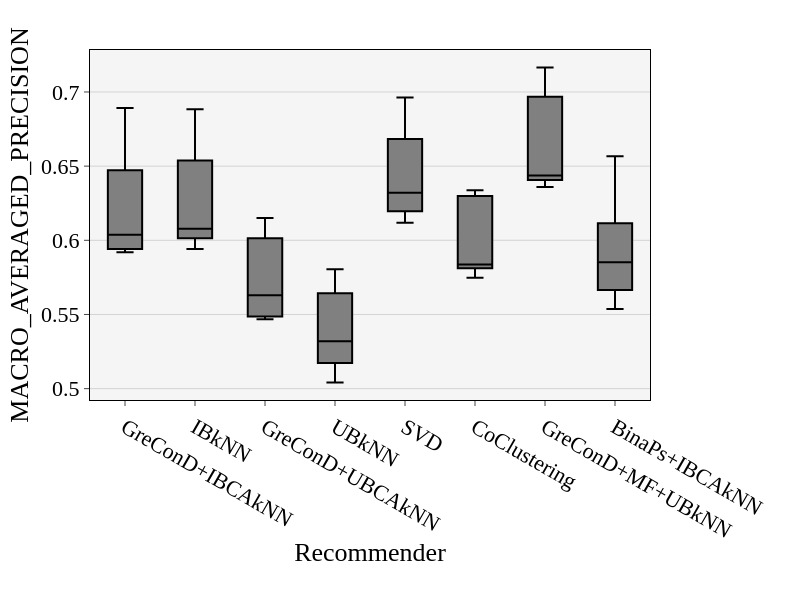

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.623 & 0.036 & 0.592 & 0.689 \\
IBkNN & 0.627 & 0.035 & 0.594 & 0.688 \\
GreConD+UBCAkNN & 0.574 & 0.027 & 0.547 & 0.615 \\
UBkNN & 0.539 & 0.027 & 0.504 & 0.581 \\
SVD & 0.644 & 0.030 & 0.612 & 0.696 \\
CoClustering & 0.601 & 0.025 & 0.575 & 0.634 \\
GreConD+MF+UBkNN & 0.666 & 0.032 & 0.636 & 0.716 \\
BinaPs+IBCAkNN & 0.593 & 0.035 & 0.554 & 0.657 \\
\bottomrule
\end{tabular}



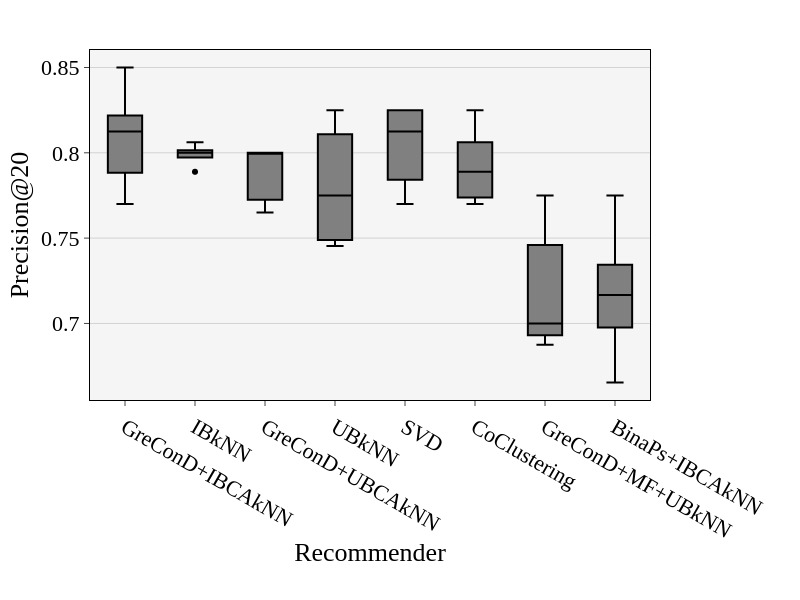

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 0.808 & 0.026 & 0.770 & 0.850 \\
IBkNN & 0.799 & 0.006 & 0.789 & 0.806 \\
GreConD+UBCAkNN & 0.788 & 0.015 & 0.765 & 0.800 \\
UBkNN & 0.780 & 0.031 & 0.745 & 0.825 \\
SVD & 0.804 & 0.022 & 0.770 & 0.825 \\
CoClustering & 0.792 & 0.020 & 0.770 & 0.825 \\
GreConD+MF+UBkNN & 0.719 & 0.033 & 0.688 & 0.775 \\
BinaPs+IBCAkNN & 0.717 & 0.035 & 0.665 & 0.775 \\
\bottomrule
\end{tabular}



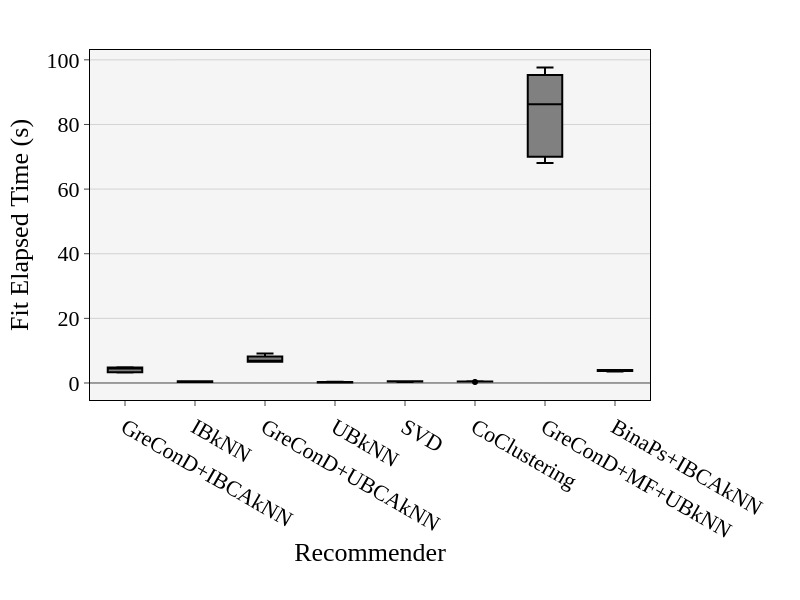

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 4.148 & 0.698 & 3.281 & 4.856 \\
IBkNN & 0.418 & 0.097 & 0.307 & 0.566 \\
GreConD+UBCAkNN & 7.403 & 1.010 & 6.549 & 9.154 \\
UBkNN & 0.241 & 0.085 & 0.150 & 0.388 \\
SVD & 0.467 & 0.092 & 0.298 & 0.572 \\
CoClustering & 0.447 & 0.067 & 0.316 & 0.510 \\
GreConD+MF+UBkNN & 83.443 & 12.077 & 68.107 & 97.628 \\
BinaPs+IBCAkNN & 3.836 & 0.171 & 3.579 & 4.032 \\
\bottomrule
\end{tabular}



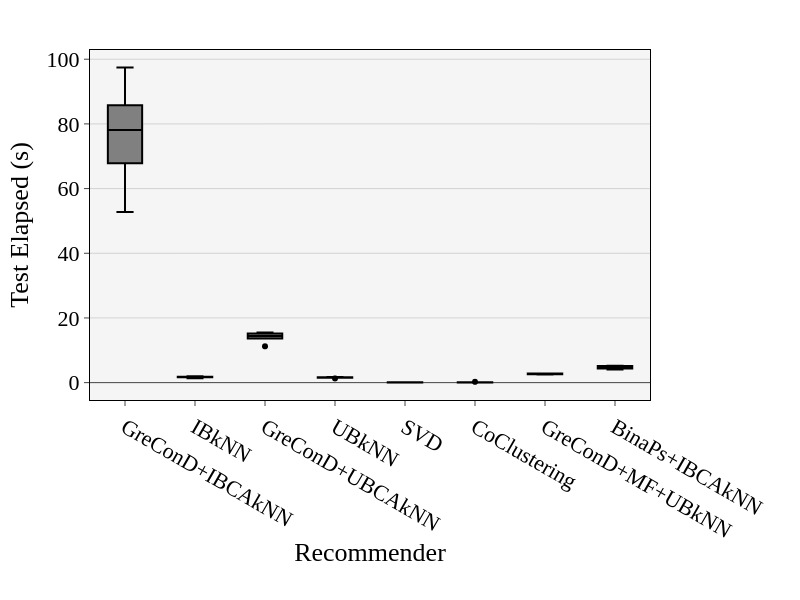

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 76.601 & 14.470 & 52.763 & 97.440 \\
IBkNN & 1.720 & 0.203 & 1.350 & 1.970 \\
GreConD+UBCAkNN & 14.136 & 1.512 & 11.227 & 15.524 \\
UBkNN & 1.598 & 0.163 & 1.291 & 1.779 \\
SVD & 0.090 & 0.026 & 0.049 & 0.120 \\
CoClustering & 0.106 & 0.079 & 0.042 & 0.262 \\
GreConD+MF+UBkNN & 2.689 & 0.120 & 2.550 & 2.856 \\
BinaPs+IBCAkNN & 4.712 & 0.426 & 4.067 & 5.236 \\
\bottomrule
\end{tabular}



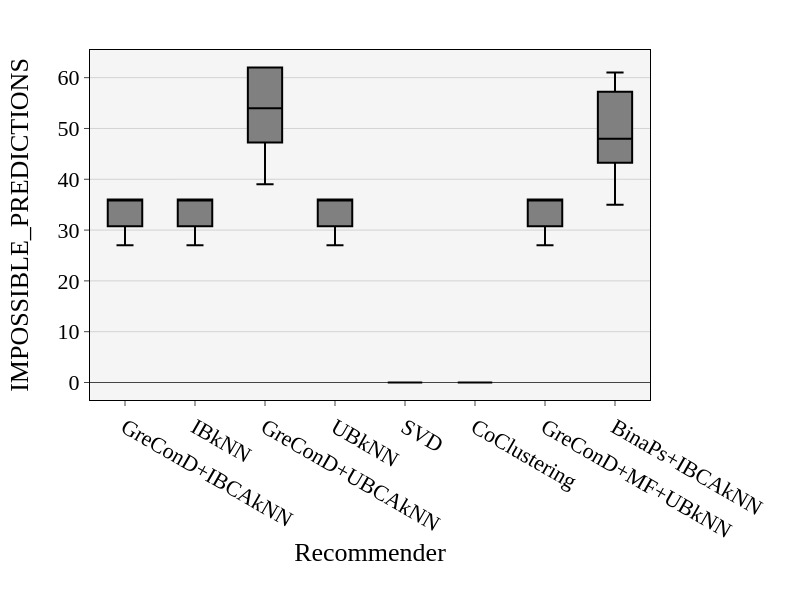

\begin{tabular}{lrrrr}
\toprule
Recommender & Mean & σ & Min & Max \\
\midrule
GreConD+IBCAkNN & 33.400 & 3.555 & 27 & 36 \\
IBkNN & 33.400 & 3.555 & 27 & 36 \\
GreConD+UBCAkNN & 53.400 & 8.570 & 39 & 62 \\
UBkNN & 33.400 & 3.555 & 27 & 36 \\
SVD & 0.000 & 0.000 & 0 & 0 \\
CoClustering & 0.000 & 0.000 & 0 & 0 \\
GreConD+MF+UBkNN & 33.400 & 3.555 & 27 & 36 \\
BinaPs+IBCAkNN & 49.200 & 8.931 & 35 & 61 \\
\bottomrule
\end{tabular}



In [36]:
# Plot results
from evaluation.plot import plot_metric_box_plot, get_result_table
from evaluation.threads import GENERIC_METRIC_NAMES


for metric_name in GENERIC_METRIC_NAMES:
    plot_metric_box_plot(metric_name, results)
    print(get_result_table(metric_name, results))

Done!
Extracting...
Done!


2024-02-07 12:05:30,529 - recommenders - INFO - Generating Formal Context...
2024-02-07 12:05:45,171 - recommenders - INFO - Generating Formal Context...
2024-02-07 12:07:59,907 - recommenders - INFO - Generating Formal Context...
2024-02-07 12:08:37,953 - recommenders - INFO - Generating Formal Context...
2024-02-07 12:11:54,321 - recommenders - INFO - Generating Formal Context...
2024-02-07 12:25:18,232 - recommenders - INFO - Generating Formal Context OK
2024-02-07 12:25:18,233 - recommenders - INFO - Generating Similarity Matrix...
2024-02-07 12:26:21,390 - recommenders - INFO - Generating Formal Context OK
2024-02-07 12:26:21,391 - recommenders - INFO - Generating Similarity Matrix...
2024-02-07 12:28:01,609 - recommenders - INFO - Generating Similarity Matrix OK
2024-02-07 12:28:10,102 - recommenders - INFO - Generating Formal Context OK
2024-02-07 12:28:10,102 - recommenders - INFO - Generating Similarity Matrix...
2024-02-07 12:29:03,776 - recommenders - INFO - Generating Simil

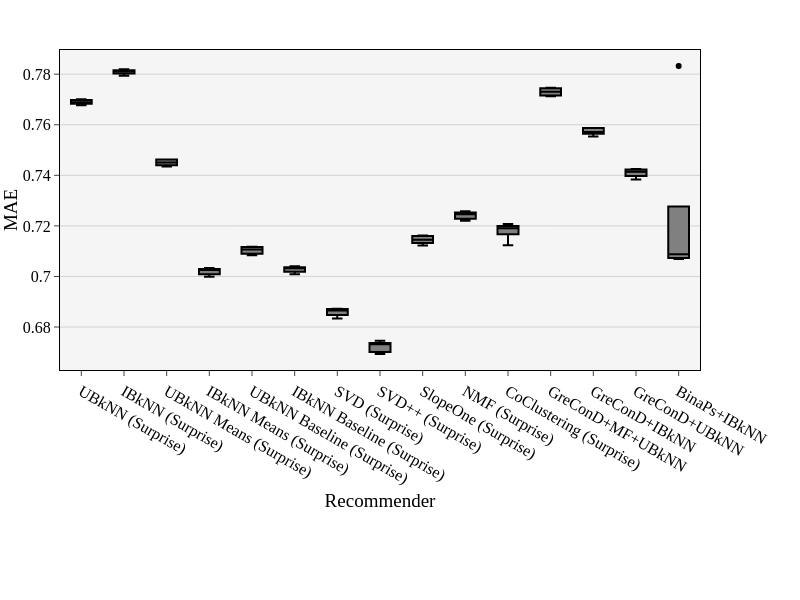

                  Recommender      Mean  Standard Deviation      Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.768977            0.000836  6.995903e-07  0.767750  0.770042  0.768903  0.768453  0.769738     0.766526     0.771666 -0.117658 -1.381102
1            IBkNN (Surprise)  0.780956            0.000899  8.083154e-07  0.779379  0.781970  0.781395  0.780613  0.781424     0.779398     0.782639 -0.751915 -0.755128
2      UBkNN Means (Surprise)  0.745041            0.001129  1.275230e-06  0.743444  0.746291  0.745106  0.744128  0.746234     0.740969     0.749394 -0.163361 -1.564311
3      IBkNN Means (Surprise)  0.701987            0.001253  1.571146e-06  0.699934  0.703397  0.702625  0.701200  0.702778     0.698834     0.705144 -0.566884 -1.163786
4   UBkNN Baseline (Surprise)  0.710326            0.001315  1.729468e-06  0.708419  0.711712  0.710650  0.709206  0.711641     0.705552     0.715294 

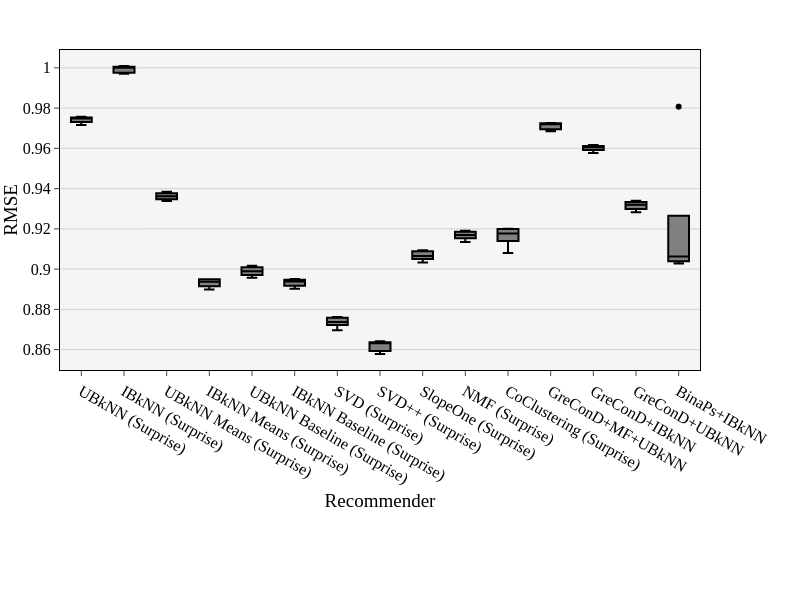

                  Recommender      Mean  Standard Deviation  Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.974216            0.001510  0.000002  0.971562  0.975712  0.975046  0.973549  0.975210     0.971058     0.977702 -0.817608 -0.836768
1            IBkNN (Surprise)  0.999265            0.001525  0.000002  0.997096  1.000915  1.000077  0.997796  1.000443     0.993825     1.004413 -0.378854 -1.648591
2      UBkNN Means (Surprise)  0.936162            0.001663  0.000003  0.933783  0.938493  0.936168  0.935012  0.937354     0.931500     0.940866 -0.027203 -1.293969
3      IBkNN Means (Surprise)  0.893106            0.001950  0.000004  0.889836  0.895017  0.893741  0.892053  0.894882     0.887809     0.899126 -0.627831 -1.077488
4   UBkNN Baseline (Surprise)  0.898920            0.002137  0.000005  0.895738  0.901671  0.898977  0.897516  0.900700     0.892740     0.905476 -0.175192 -1.334270
5   

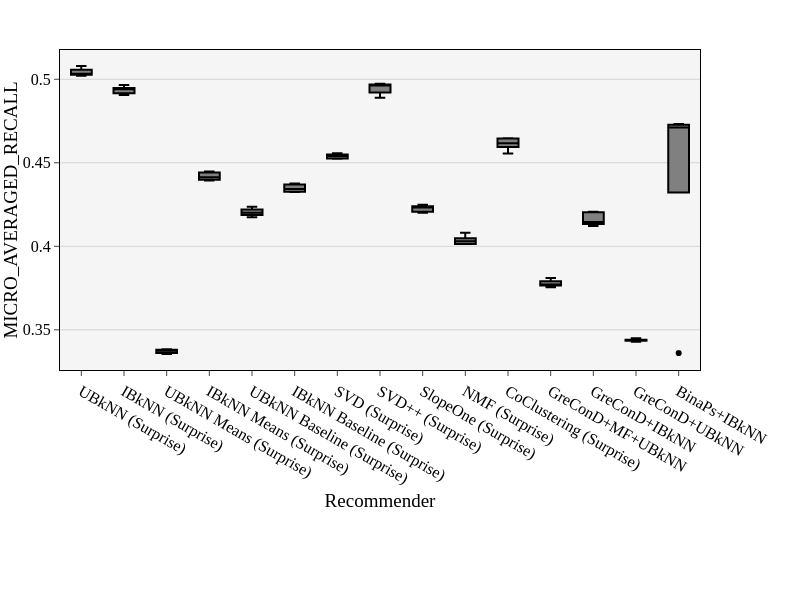

                  Recommender      Mean  Standard Deviation      Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.504198            0.002080  4.325385e-06  0.502034  0.507937  0.503210  0.502950  0.504858     0.500088     0.507719  0.878694 -0.638888
1            IBkNN (Surprise)  0.493490            0.002067  4.274178e-06  0.490588  0.496624  0.494044  0.491976  0.494219     0.488613     0.497583  0.077006 -1.106352
2      UBkNN Means (Surprise)  0.337170            0.001078  1.161476e-06  0.335525  0.338404  0.337559  0.336336  0.338024     0.333802     0.340558 -0.393670 -1.416355
3      IBkNN Means (Surprise)  0.441896            0.002173  4.722596e-06  0.439458  0.444820  0.441287  0.439868  0.444049     0.433596     0.450320  0.231702 -1.682159
4   UBkNN Baseline (Surprise)  0.420363            0.002082  4.334595e-06  0.417424  0.423618  0.420071  0.419268  0.421437     0.416014     0.424690 

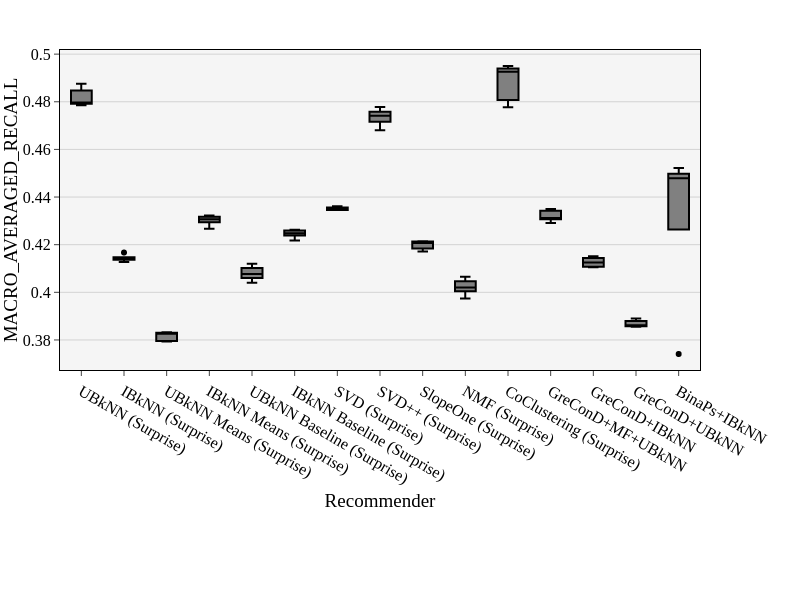

                  Recommender      Mean  Standard Deviation      Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.481810            0.003419  1.168997e-05  0.478556  0.487607  0.479737  0.479356  0.483792     0.472701     0.490447  0.723296 -1.079629
1            IBkNN (Surprise)  0.414299            0.001305  1.704000e-06  0.412719  0.416705  0.414030  0.413963  0.414077     0.413791     0.414249  0.892515 -0.260195
2      UBkNN Means (Surprise)  0.381613            0.001750  3.064234e-06  0.379337  0.383267  0.382891  0.379617  0.382951     0.374616     0.387951 -0.399485 -1.806580
3      IBkNN Means (Surprise)  0.430325            0.001927  3.712852e-06  0.426718  0.432282  0.430645  0.430385  0.431597     0.428568     0.433414 -1.044975 -0.291922
4   UBkNN Baseline (Surprise)  0.408003            0.002683  7.200853e-06  0.404051  0.411974  0.407686  0.406657  0.409648     0.402171     0.414133 

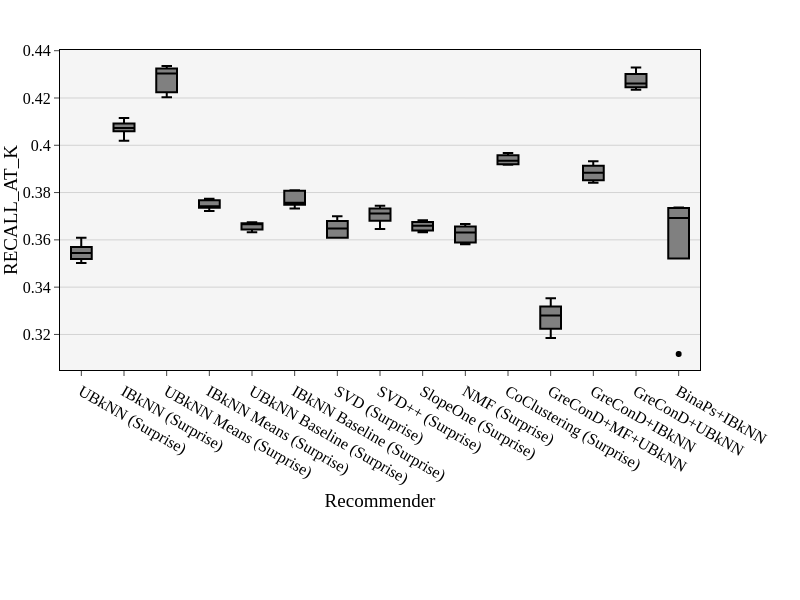

                  Recommender      Mean  Standard Deviation  Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.354732            0.003584  0.000013  0.350178  0.360858  0.354482  0.352485  0.355660     0.347722     0.360422  0.541928 -0.741073
1            IBkNN (Surprise)  0.407318            0.003100  0.000010  0.401961  0.411581  0.407330  0.407314  0.408407     0.405675     0.410046 -0.503599 -0.498568
2      UBkNN Means (Surprise)  0.427896            0.005221  0.000027  0.420298  0.433532  0.430409  0.423129  0.432113     0.409654     0.445589 -0.389378 -1.596925
3      IBkNN Means (Surprise)  0.374865            0.001845  0.000003  0.372244  0.377393  0.374226  0.373990  0.376473     0.370267     0.380196  0.043341 -1.351839
4   UBkNN Baseline (Surprise)  0.365844            0.001591  0.000003  0.363205  0.367439  0.366865  0.364829  0.366883     0.361748     0.369964 -0.654730 -1.181367
5   

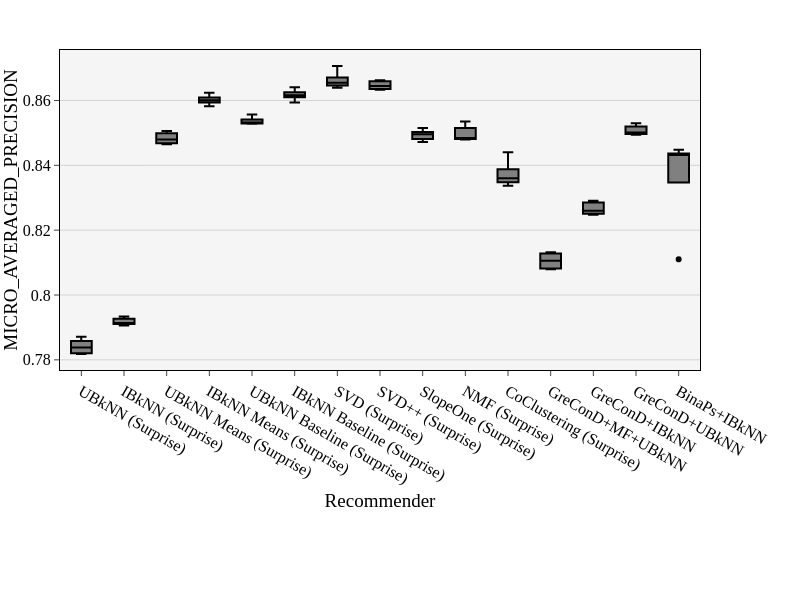

                  Recommender      Mean  Standard Deviation  Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.784049            0.001999  0.000004  0.781805  0.787114  0.783831  0.782115  0.785378     0.777221     0.790273  0.315740 -1.363224
1            IBkNN (Surprise)  0.791762            0.001015  0.000001  0.790562  0.793376  0.791218  0.791194  0.792458     0.789300     0.794352  0.474036 -1.246510
2      UBkNN Means (Surprise)  0.848329            0.001575  0.000002  0.846474  0.850598  0.847994  0.846931  0.849646     0.842857     0.853720  0.247649 -1.528097
3      IBkNN Means (Surprise)  0.860167            0.001323  0.000002  0.858248  0.862366  0.860086  0.859748  0.860387     0.858788     0.861347  0.303231 -0.584466
4   UBkNN Baseline (Surprise)  0.853647            0.001061  0.000001  0.852853  0.855696  0.853132  0.852914  0.853642     0.851823     0.854734  1.265712 -0.103675
5   

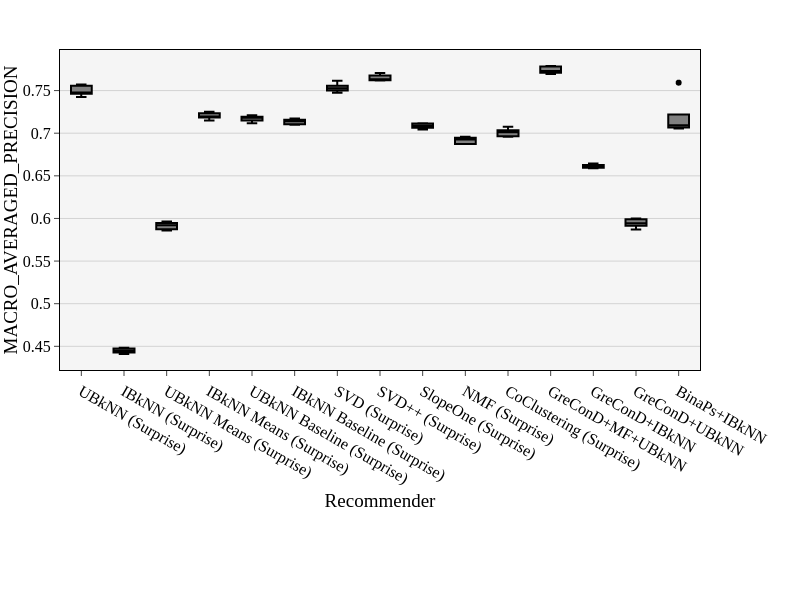

                  Recommender      Mean  Standard Deviation  Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.750010            0.005385  0.000029  0.742567  0.757151  0.747688  0.747464  0.755179     0.735891     0.766752  0.078133 -1.464812
1            IBkNN (Surprise)  0.444888            0.002657  0.000007  0.440992  0.448208  0.444672  0.443192  0.447375     0.436917     0.453650 -0.128253 -1.402288
2      UBkNN Means (Surprise)  0.591246            0.003955  0.000016  0.585737  0.596551  0.592002  0.587886  0.594051     0.578638     0.603300 -0.107264 -1.445228
3      IBkNN Means (Surprise)  0.720362            0.003423  0.000012  0.714996  0.725045  0.719521  0.719395  0.722853     0.714209     0.728039 -0.188882 -1.032461
4   UBkNN Baseline (Surprise)  0.717153            0.003114  0.000010  0.711814  0.720995  0.718236  0.715954  0.718766     0.711734     0.722986 -0.607816 -0.786117
5   

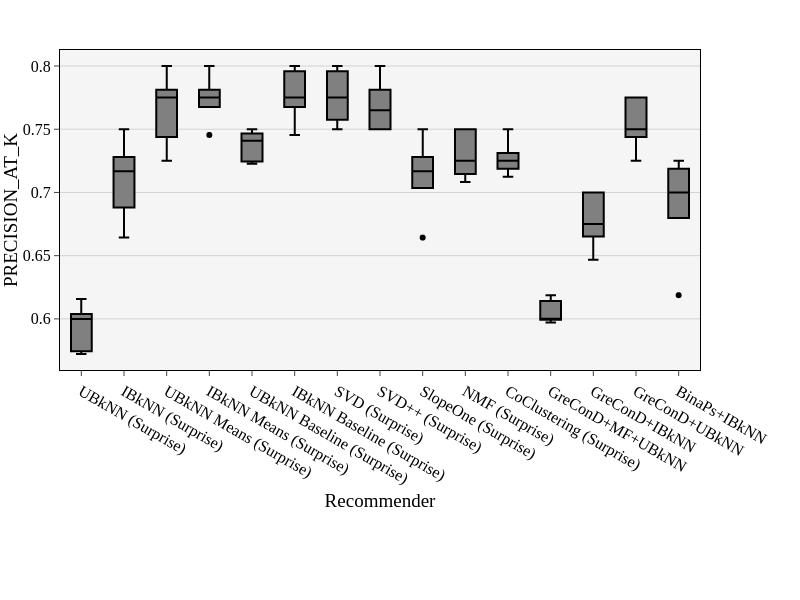

                  Recommender      Mean  Standard Deviation  Variance       Min       Max    Median        Q1        Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  0.592569            0.016521  0.000273  0.572222  0.615625  0.600000  0.575000  0.600000     0.537500     0.637500 -0.034218 -1.509029
1            IBkNN (Surprise)  0.709588            0.028434  0.000808  0.664286  0.750000  0.716667  0.696154  0.720833     0.659135     0.757853 -0.240313 -0.879607
2      UBkNN Means (Surprise)  0.765000            0.025495  0.000650  0.725000  0.800000  0.775000  0.750000  0.775000     0.712500     0.812500 -0.271545 -1.044379
3      IBkNN Means (Surprise)  0.774091            0.017285  0.000299  0.745455  0.800000  0.775000  0.775000  0.775000     0.775000     0.775000 -0.235805 -0.483494
4   UBkNN Baseline (Surprise)  0.736818            0.010985  0.000121  0.722727  0.750000  0.740909  0.725000  0.745455     0.694318     0.776136 -0.218097 -1.695428
5   

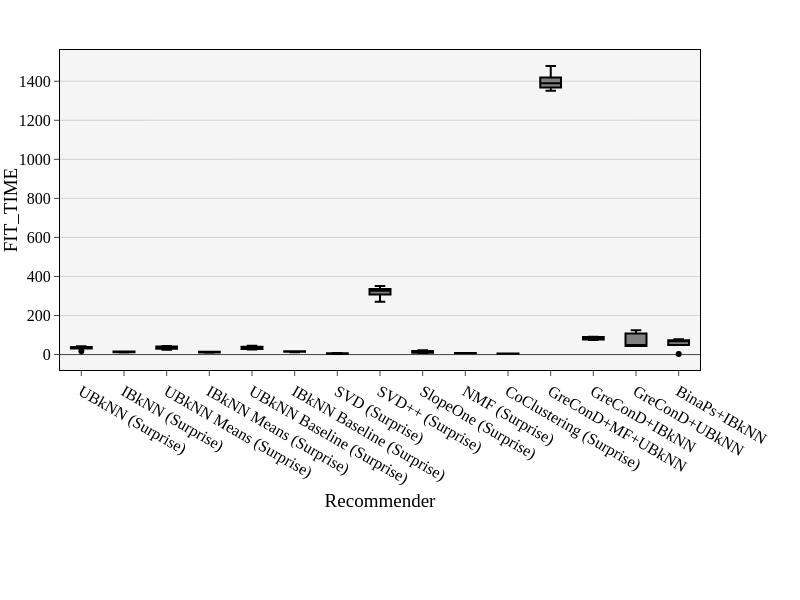

                  Recommender         Mean  Standard Deviation     Variance          Min          Max       Median           Q1           Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)    34.040332            8.891135    79.052289    17.056906    43.182936    37.173299    35.312580    37.475937    32.067545    40.720973 -1.155579 -0.106192
1            IBkNN (Surprise)    13.471014            2.103485     4.424650    10.633562    15.950420    13.175849    11.845159    15.750078     5.987781    21.607457 -0.001900 -1.604664
2      UBkNN Means (Surprise)    35.438372            6.831500    46.669390    24.497038    43.662672    37.602220    31.178458    40.251472    17.568937    53.860994 -0.444892 -1.182387
3      IBkNN Means (Surprise)    12.891450            2.238976     5.013012     9.135561    15.073741    14.302593    11.525018    14.420338     7.182040    18.763317 -0.690623 -1.132970
4   UBkNN Baseline (Surprise)    35.043611            6.726110   

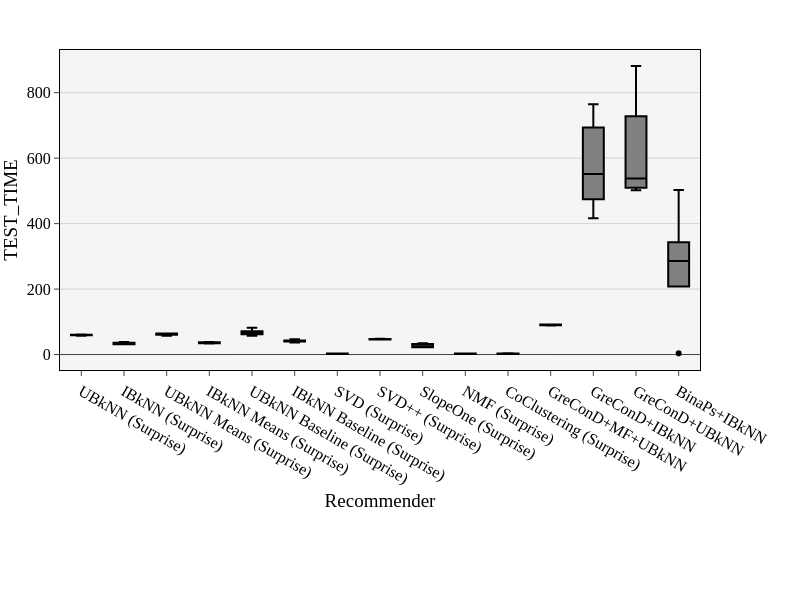

                  Recommender        Mean  Standard Deviation      Variance         Min         Max      Median          Q1          Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)   59.831060            1.297617      1.683810   57.427282   61.330254   60.138887   59.883976   60.374900    59.147588    61.111288 -0.945532 -0.281684
1            IBkNN (Surprise)   34.330450            2.597750      6.748307   31.393308   38.410208   34.949557   31.641941   35.257235    26.218999    40.680177  0.275723 -1.223137
2      UBkNN Means (Surprise)   62.057089            2.711582      7.352675   57.149358   64.403951   63.634742   61.099999   63.997393    56.753909    68.343483 -0.952240 -0.663157
3      IBkNN Means (Surprise)   36.050457            1.517002      2.301295   34.003746   38.096810   35.715469   35.001281   37.434980    31.350734    41.085528  0.083470 -1.490079
4   UBkNN Baseline (Surprise)   67.246904            8.182930     66.960338   57.589959   

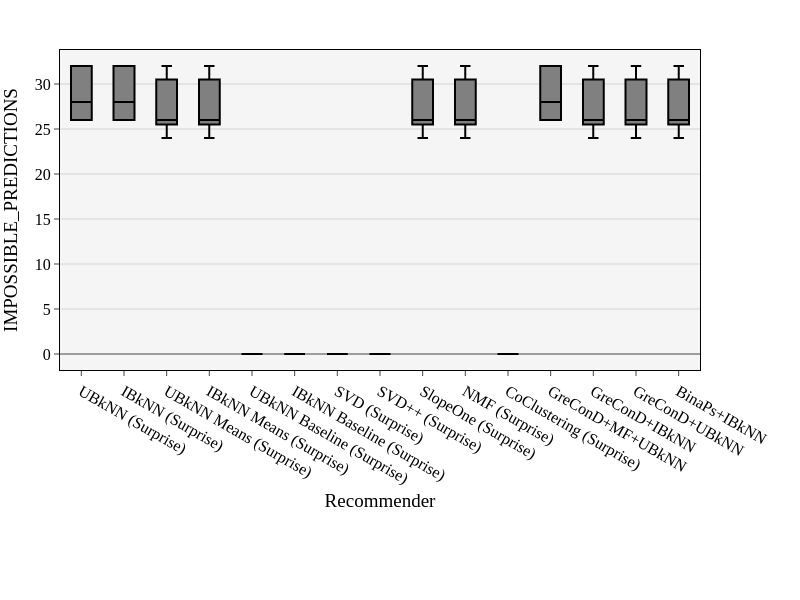

                  Recommender  Mean  Standard Deviation  Variance  Min  Max  Median    Q1    Q3  Lower Fence  Upper Fence  Skewness  Kurtosis
0            UBkNN (Surprise)  28.8            2.712932      7.36   26   32    28.0  26.0  32.0         17.0         41.0  0.211547 -1.770321
1            IBkNN (Surprise)  28.8            2.712932      7.36   26   32    28.0  26.0  32.0         17.0         41.0  0.211547 -1.770321
2      UBkNN Means (Surprise)  27.6            2.939388      8.64   24   32    26.0  26.0  30.0         20.0         36.0  0.347767 -1.421811
3      IBkNN Means (Surprise)  27.6            2.939388      8.64   24   32    26.0  26.0  30.0         20.0         36.0  0.347767 -1.421811
4   UBkNN Baseline (Surprise)   0.0            0.000000      0.00    0    0     0.0   0.0   0.0          0.0          0.0       NaN       NaN
5   IBkNN Baseline (Surprise)   0.0            0.000000      0.00    0    0     0.0   0.0   0.0          0.0          0.0       NaN       NaN
6     

In [24]:
# Benchmark MovieLens 1M
from dataset.movie_lens import load_ml_1m_folds
from surprise.prediction_algorithms import KNNBasic, SVD, KNNWithMeans, KNNBaseline
from recommenders import grecond_recommender, binaps_based_recommenders
import evaluation.threads as threads
from evaluation.plot import benchmark
from evaluation.threads import generic_benchmark_thread
from evaluation.plot import plot_metric_box_plot, get_result_table
from evaluation.threads import GENERIC_METRIC_NAMES

folds = load_ml_1m_folds()

# For MovieLens 1M, the best results were obtained with the following parameter:
GRECOND_COVERAGE = 0.2


parallel_recommender_variations = [
    threads.RecommenderVariation(
        "UBkNN (Surprise)",
        KNNBasic(k=KNN_K, sim_options={"name": "cosine", "user_based": True}, verbose=False),
    ),
    threads.RecommenderVariation(
        "IBkNN (Surprise)",
        KNNBasic(k=KNN_K, sim_options={"name": "cosine", "user_based": False}, verbose=False),
    ),
    threads.RecommenderVariation(
        "UBkNN Means (Surprise)",
        KNNWithMeans(k=KNN_K, sim_options={"name": "cosine", "user_based": True}, verbose=False),
    ),
    threads.RecommenderVariation(
        "IBkNN Means (Surprise)",
        KNNWithMeans(k=KNN_K, sim_options={"name": "cosine", "user_based": False}, verbose=False),
    ),
    threads.RecommenderVariation(
        "UBkNN Baseline (Surprise)",
        KNNBaseline(k=KNN_K, sim_options={"name": "cosine", "user_based": True}, verbose=False),
    ),
    threads.RecommenderVariation(
        "IBkNN Baseline (Surprise)",
        KNNBaseline(k=KNN_K, sim_options={"name": "cosine", "user_based": False}, verbose=False),
    ),
    threads.RecommenderVariation("SVD (Surprise)", SVD(verbose=False)),
    threads.RecommenderVariation("SVD++ (Surprise)", SVDpp(verbose=False)),
    threads.RecommenderVariation("SlopeOne (Surprise)", SlopeOne()),
    threads.RecommenderVariation("NMF (Surprise)", NMF(verbose=False)),
    threads.RecommenderVariation("CoClustering (Surprise)", CoClustering(verbose=False)),
    (
        "GreConD+MF+UBkNN",
        grecond_recommender.GreConDKNNRecommender(
            grecond_coverage=1.0,
            dataset_binarization_threshold=1.0,
            knn_k=30,
            knn_distance_strategy=common.get_cosine_similarity_matrix,
        ),
    ),
    threads.RecommenderVariation(
        "GreConD+IBkNN",
        grecond_recommender.GreConDBiAKNNRecommender(
            grecond_coverage=GRECOND_COVERAGE,
            dataset_binarization_threshold=DATASET_BINARIZATION_THRESHOLD,
            minimum_bicluster_sparsity=MINIMUM_BICLUSTER_SPARSITY,
            minimum_bicluster_coverage=MINIMUM_BICLUSTER_COVERAGE,
            minimum_bicluster_relative_size=MINIMUM_BICLUSTER_RELATIVE_SIZE,
            knn_type="item",
            user_binarization_threshold=USER_BINARIZATION_THRESHOLD,
            number_of_top_k_biclusters=NUMBER_OF_TOP_K_BICLUSTERS,
            knn_k=KNN_K,
        ),
    ),
    threads.RecommenderVariation(
        "GreConD+UBkNN",
        grecond_recommender.GreConDBiAKNNRecommender(
            grecond_coverage=GRECOND_COVERAGE,
            dataset_binarization_threshold=DATASET_BINARIZATION_THRESHOLD,
            minimum_bicluster_sparsity=MINIMUM_BICLUSTER_SPARSITY,
            minimum_bicluster_coverage=MINIMUM_BICLUSTER_COVERAGE,
            minimum_bicluster_relative_size=MINIMUM_BICLUSTER_RELATIVE_SIZE,
            knn_type="user",
            user_binarization_threshold=USER_BINARIZATION_THRESHOLD,
            number_of_top_k_biclusters=NUMBER_OF_TOP_K_BICLUSTERS,
            knn_k=KNN_K,
        ),
    ),
]


sequential_recommender_variations = [
    threads.RecommenderVariation(
        "BinaPs+IBkNN",
        binaps_based_recommenders.BinaPsKNNRecommender(
            epochs=EPOCHS,
            dataset_binarization_threshold=DATASET_BINARIZATION_THRESHOLD,
            minimum_bicluster_sparsity=MINIMUM_BICLUSTER_SPARSITY,
            minimum_bicluster_coverage=MINIMUM_BICLUSTER_COVERAGE,
            minimum_bicluster_relative_size=MINIMUM_BICLUSTER_RELATIVE_SIZE,
            knn_type="item",
            user_binarization_threshold=USER_BINARIZATION_THRESHOLD,
            number_of_top_k_biclusters=NUMBER_OF_TOP_K_BICLUSTERS,
            knn_k=KNN_K,
        ),
    )
]

results = benchmark(
    folds,
    parallel_recommender_variations,
    sequential_recommender_variations,
    REPEAT,
    RELEVANCE_THRESHOLD,
    NUMBER_OF_TOP_RECOMMENDATIONS,
    generic_benchmark_thread,
)

for metric_name in GENERIC_METRIC_NAMES:
    plot_metric_box_plot(metric_name, results)
    print(get_result_table(metric_name, results))